In [1]:
import numpy as np
import os
import gc
import time
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
    f1_score
)


2026-02-08 07:12:00.900028: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-08 07:12:01.006143: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770509521.051939   65236 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770509521.067073   65236 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770509521.161866   65236 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
DWT_TRAIN_DIR = "/home/dani/Documents/tugas akhir/TugasAkhirku2026/tow_ids/Preprocessing/hasil/dwt/train"
DWT_TEST_DIR  = "/home/dani/Documents/tugas akhir/TugasAkhirku2026/tow_ids/Preprocessing/hasil/dwt/test"


In [ ]:
def build_cnn_tow_ids():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(128, activation="relu"),
        layers.Dense(1, activation="sigmoid")  # Binary IDS
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


In [28]:
from collections import Counter

# contoh ambil satu part dulu (atau gabungan statistik)
counter = Counter(y_true)  # atau y_train sample
counter


Counter({np.int64(0): 438070, np.int64(1): 353478})

In [ ]:
total = 438070 + 353478

class_weight = {
    0: total / (2 * 438070),  # Normal
    1: total / (2 * 353478)   # Attack
}

class_weight


In [ ]:
model = build_cnn_tow_ids()

EPOCHS = 5          # naikkan nanti
BATCH_SIZE = 32

train_parts = sorted([
    f for f in os.listdir(DWT_TRAIN_DIR)
    if f.endswith(".npz")
])

history_all = {"loss": [], "accuracy": []}

for part in train_parts:
    print(f"Training on {part}")

    data = np.load(os.path.join(DWT_TRAIN_DIR, part))
    X = data["X"]
    y = data["y"]

    history = model.fit(
        X, y,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        verbose=1
    )

    history_all["loss"].extend(history.history["loss"])
    history_all["accuracy"].extend(history.history["accuracy"])

    del X, y, data
    gc.collect()


2026-02-08 07:12:35.007374: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Training on train_dwt_part_001.npz
Epoch 1/5
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 1.0000 - loss: 0.0014
Epoch 2/5
443/443 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 1.0000 - loss: 3.7771e-24
Epoch 3/5
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 3.7771e-24
Epoch 4/5
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 1.0000 - loss: 3.7771e-24
Epoch 5/5
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 3.7771e-24
Training on train_dwt_part_002.npz
Epoch 1/5
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 2.2408e-24
Epoch 2/5
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 2.2408e-24
Epoch 3/5
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 2.2408e-24
Epoch 4/5
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 2.2408e-24
Epoch 5/5
443/443 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 1.0000 - loss: 2.2408e-24
Training on train_dwt_part_003.npz
Epoch 1/5

In [5]:
y_true = []
y_prob = []

test_parts = sorted([
    f for f in os.listdir(DWT_TEST_DIR)
    if f.endswith(".npz")
])

for part in test_parts:
    data = np.load(os.path.join(DWT_TEST_DIR, part))
    X = data["X"]
    y = data["y"]

    probs = model.predict(X).ravel()

    y_true.extend(y)
    y_prob.extend(probs)

    del X, y, data
    gc.collect()

y_true = np.array(y_true)
y_prob = np.array(y_prob)


292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
292/292 ━━━━━━━━

In [6]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
youden_index = tpr - fpr
best_threshold = thresholds[np.argmax(youden_index)]

print(f"Threshold Optimal (Youden): {best_threshold:.4f}")


Threshold Optimal (Youden): 0.0000


In [7]:
y_pred = (y_prob >= best_threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("TP:", tp)
print("FP:", fp)
print("TN:", tn)
print("FN:", fn)


TP: 88015
FP: 10945
TN: 427125
FN: 265463


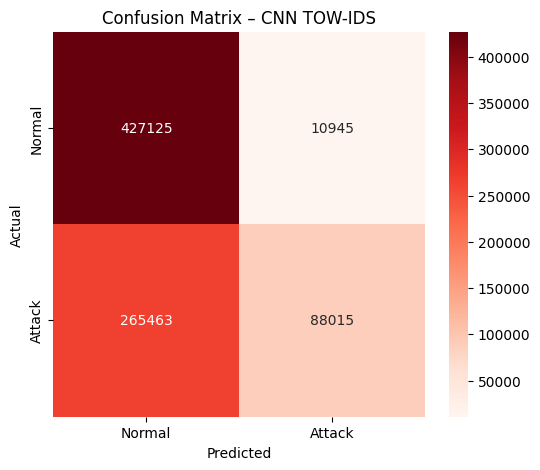

In [8]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Reds",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)
plt.title("Confusion Matrix – CNN TOW-IDS")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [9]:
acc = (tp + tn) / (tp + tn + fp + fn)
f1  = (2 * tp) / (2 * tp + fp + fn)
fpr_val = fp / (fp + tn)
fnr_val = fn / (fn + tp)

print("\n=== HASIL IDS (CNN TOW-IDS) ===")
print(f"Accuracy : {acc:.6f}")
print(f"F1-score : {f1:.6f}")
print(f"FPR      : {fpr_val:.6f}")
print(f"FNR      : {fnr_val:.6f}")



=== HASIL IDS (CNN TOW-IDS) ===
Accuracy : 0.650801
F1-score : 0.389070
FPR      : 0.024985
FNR      : 0.751003


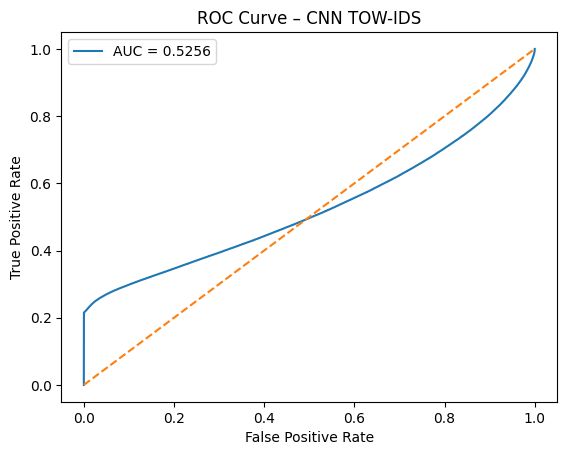

In [10]:
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – CNN TOW-IDS")
plt.legend()
plt.show()


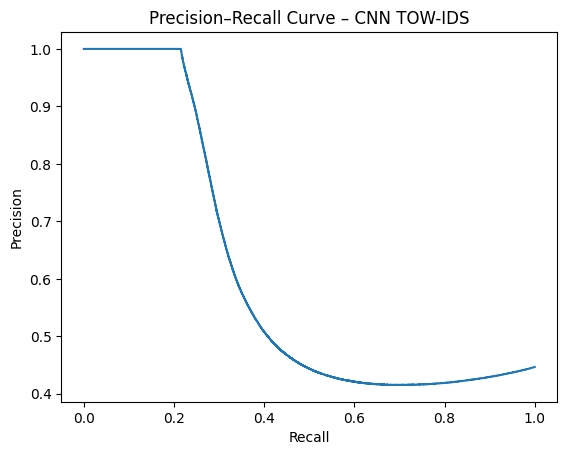

In [11]:
prec, rec, _ = precision_recall_curve(y_true, y_prob)

plt.figure()
plt.plot(rec, prec)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve – CNN TOW-IDS")
plt.show()


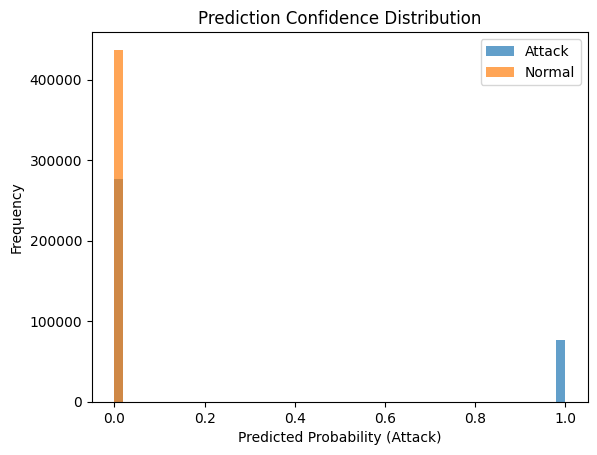

In [12]:
plt.figure()
plt.hist(y_prob[y_true == 1], bins=50, alpha=0.7, label="Attack")
plt.hist(y_prob[y_true == 0], bins=50, alpha=0.7, label="Normal")
plt.xlabel("Predicted Probability (Attack)")
plt.ylabel("Frequency")
plt.title("Prediction Confidence Distribution")
plt.legend()
plt.show()


In [13]:
print(classification_report(
    y_true, y_pred,
    target_names=["Normal", "Attack"]
))


              precision    recall  f1-score   support

      Normal       0.62      0.98      0.76    438070
      Attack       0.89      0.25      0.39    353478

    accuracy                           0.65    791548
   macro avg       0.75      0.61      0.57    791548
weighted avg       0.74      0.65      0.59    791548



In [15]:
import time
import numpy as np
import os

# ambil 1 part test
sample_part = os.path.join(
    DWT_TEST_DIR,
    "test_dwt_part_001.npz"
)

data = np.load(sample_part)
X_sample = data["X"][:128]   # batch kecil saja

start = time.time()
_ = model.predict(X_sample, verbose=0)
latency = (time.time() - start) / X_sample.shape[0]

print(f"Inference Latency: {latency:.6f} s/sample")

del X_sample, data


Inference Latency: 0.000359 s/sample


In [16]:
print("y_prob min:", y_prob.min())
print("y_prob max:", y_prob.max())
print("y_prob mean:", y_prob.mean())

np.percentile(y_prob, [1, 5, 10, 50, 90, 95, 99])


y_prob min: 1.7849234e-24
y_prob max: 1.0
y_prob mean: 0.096746795


array([1.81837931e-15, 1.14110522e-13, 1.05179331e-12, 3.27246086e-09,
       5.83164310e-03, 1.00000000e+00, 1.00000000e+00])

ganti youden predict


In [17]:
y_pred_05 = (y_prob >= 0.5).astype(int)


In [18]:
from sklearn.metrics import confusion_matrix, classification_report

# confusion matrix threshold 0.5
cm_05 = confusion_matrix(y_true, y_pred_05)
tn, fp, fn, tp = cm_05.ravel()

print("=== Threshold 0.5 ===")
print("TP:", tp)
print("FP:", fp)
print("TN:", tn)
print("FN:", fn)

acc_05 = (tp + tn) / (tp + tn + fp + fn)
f1_05  = (2 * tp) / (2 * tp + fp + fn)
fpr_05 = fp / (fp + tn)
fnr_05 = fn / (fn + tp)

print(f"Accuracy : {acc_05:.6f}")
print(f"F1-score : {f1_05:.6f}")
print(f"FPR      : {fpr_05:.6f}")
print(f"FNR      : {fnr_05:.6f}")

print("\nClassification report (0.5):")
print(classification_report(
    y_true, y_pred_05,
    target_names=["Normal", "Attack"]
))


=== Threshold 0.5 ===
TP: 76262
FP: 183
TN: 437887
FN: 277216
Accuracy : 0.649549
F1-score : 0.354771
FPR      : 0.000418
FNR      : 0.784252

Classification report (0.5):
              precision    recall  f1-score   support

      Normal       0.61      1.00      0.76    438070
      Attack       1.00      0.22      0.35    353478

    accuracy                           0.65    791548
   macro avg       0.80      0.61      0.56    791548
weighted avg       0.78      0.65      0.58    791548



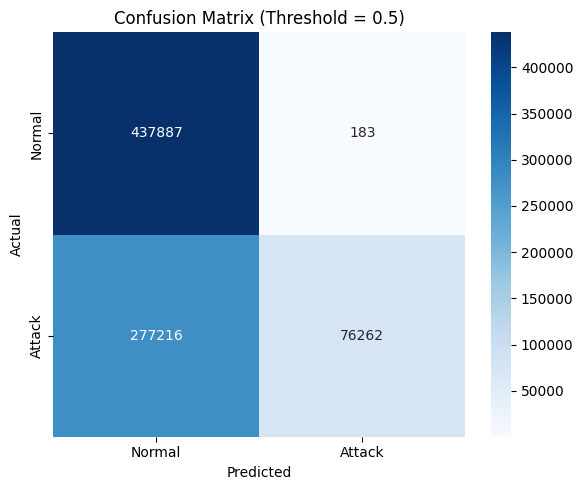

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_05 = confusion_matrix(y_true, y_pred_05)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_05,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Attack"],
    yticklabels=["Normal", "Attack"]
)
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


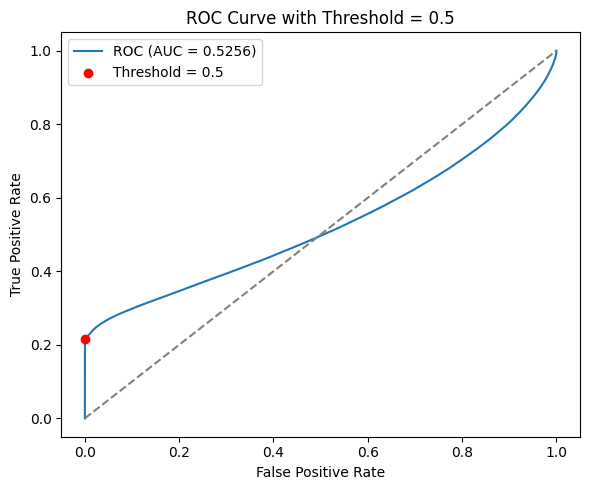

In [23]:
from sklearn.metrics import roc_curve, auc
import numpy as np

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

# cari titik threshold terdekat ke 0.5
idx_05 = np.argmin(np.abs(thresholds - 0.5))

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {roc_auc:.4f})")
plt.scatter(
    fpr[idx_05],
    tpr[idx_05],
    color="red",
    label="Threshold = 0.5",
    zorder=5
)
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve with Threshold = 0.5")
plt.legend()
plt.tight_layout()
plt.show()


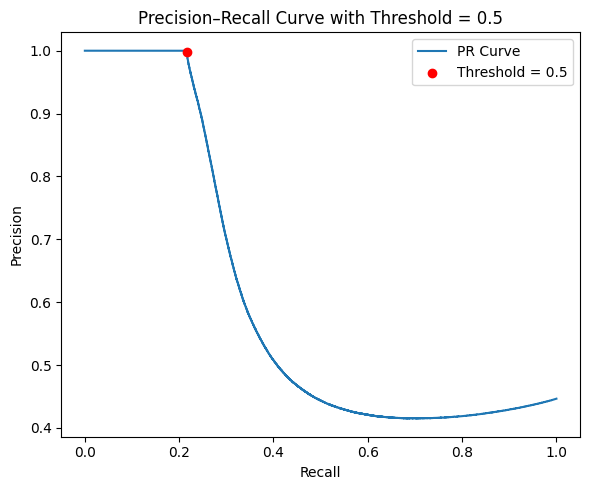

In [21]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_prob)

# cari threshold terdekat 0.5 di PR curve
idx_05_pr = np.argmin(np.abs(pr_thresholds - 0.5))

plt.figure(figsize=(6,5))
plt.plot(recall, precision, label="PR Curve")
plt.scatter(
    recall[idx_05_pr],
    precision[idx_05_pr],
    color="red",
    label="Threshold = 0.5",
    zorder=5
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve with Threshold = 0.5")
plt.legend()
plt.tight_layout()
plt.show()


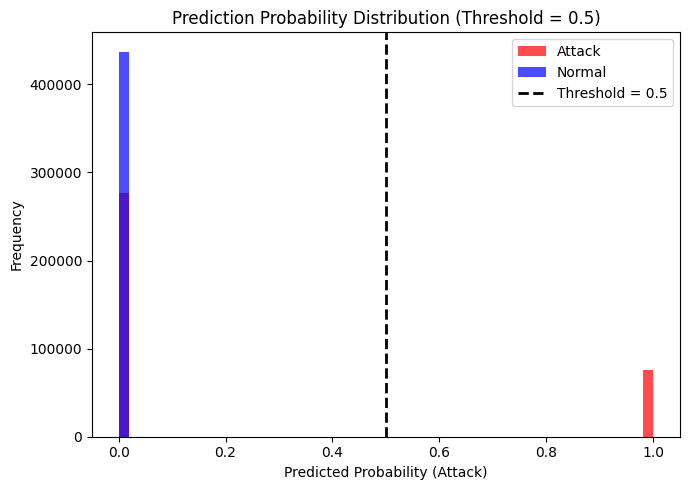

In [24]:
plt.figure(figsize=(7,5))
plt.hist(
    y_prob[y_true == 1],
    bins=50,
    alpha=0.7,
    label="Attack",
    color="red"
)
plt.hist(
    y_prob[y_true == 0],
    bins=50,
    alpha=0.7,
    label="Normal",
    color="blue"
)

plt.axvline(
    0.5,
    color="black",
    linestyle="--",
    linewidth=2,
    label="Threshold = 0.5"
)

plt.xlabel("Predicted Probability (Attack)")
plt.ylabel("Frequency")
plt.title("Prediction Probability Distribution (Threshold = 0.5)")
plt.legend()
plt.tight_layout()
plt.show()


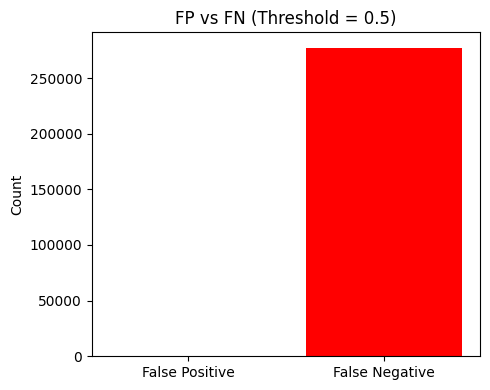

In [25]:
plt.figure(figsize=(5,4))
plt.bar(
    ["False Positive", "False Negative"],
    [fp, fn],
    color=["orange", "red"]
)
plt.title("FP vs FN (Threshold = 0.5)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


perbaikan

{0: 0.9034492204442213, 1: 1.1196566688733103}